In [2]:
#📍 WORKING DIRECTORY CHECK
import os
os.getcwd()

'C:\\Users\\kramo\\OneDrive\\Documents\\Desktop\\Projects\\telecom-churn-analysis\\notebooks'

In [3]:
# import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Set style for better-looking plots
pd.set_option('display.width', 200)



In [5]:
# ============================================================================
# STEP 1: LOAD CLEANED DATA
# ============================================================================
df = pd.read_csv('../data/processed/telecom_churn_cleaned.csv')
print(df)

      customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity  ... TechSupport StreamingTV StreamingMovies        Contract  \
0     7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL             No  ...          No          No              No  Month-to-month   
1     5575-GNVDE    Male              0      No         No      34          Yes                No             DSL            Yes  ...          No          No              No        One year   
2     3668-QPYBK    Male              0      No         No       2          Yes                No             DSL            Yes  ...          No          No              No  Month-to-month   
3     7795-CFOCW    Male              0      No         No      45           No  No phone service             DSL            Yes  ...         Yes          No              No        One year   
4     9237-HQITU  Female           

In [6]:
df. head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [7]:
df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [8]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [9]:
# QUICK OVERVIEW

#Churn Distribution:
print(f"\nChurn Distribution:")
print(df['Churn'].value_counts())

#Baseline Churn Rate
print(f"\nBaseline Churn Rate: {df['Churn_Binary'].mean()*100:.2f}%")


#Total Annual Revenue Loss
avg_monthly_charges = df['MonthlyCharges'].mean()
total_churn = df[df['Churn'] == 'Yes'].value_counts().sum()
total_annual_loss = avg_monthly_charges*total_churn*12
print(f'Total Annual Revenue Loss: ${total_annual_loss:,.0f}')



Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Baseline Churn Rate: 26.54%
Total Annual Revenue Loss: $1,452,475


#### Note: 
The DAX dashboard calculation of \\$1,669,570 is more precise than the \\$1,452,475 approximation used in this notebook, as it sums individual customer charges rather than using averages. The dashboard figure should be referenced as the definitive revenue loss figure.

## Investigation 1 — Internet Service & Churn

Which internet service type (Fiber Optic, DSL, None) has the highest churn rate, and what does this mean for how CS teams should prioritize their accounts?

In [10]:
InternetService_churn = df.groupby('InternetService')['Churn_Binary'].mean().round(2)*100
InternetService_churn = InternetService_churn.reset_index()
InternetService_churn.columns = ['InternetService','churn_rate']
print('\nChurn Rate by InternetService:')
print(InternetService_churn)


Churn Rate by InternetService:
  InternetService  churn_rate
0             DSL        19.0
1     Fiber optic        42.0
2              No         7.0


### Investigation 1 — Insight & Recommendation

Fiber Optic service records the highest churn rate at approximately 42%, more than double the DSL churn rate of 19% and nearly six times higher than customers with no internet service at 7.4%. This makes Fiber Optic the highest priority segment for CS intervention. Given the scale of this churn risk, recommended actions include proactive outreach and structured check-ins to understand the specific challenges Fiber Optic customers are experiencing. Additionally, retention strategies proving effective in DSL and non-internet segments should be evaluated for compatibility and relevance to this group.

## Investigation 2 — Contract Type & Churn

How dramatically does contract type affect churn risk, and which contract segment should be the CS team's #1 focus for proactive intervention?

In [11]:
ContractType_churn = df.groupby('Contract')['Churn_Binary'].agg(['count', 'sum', 'mean'])
ContractType_churn.columns = ['Total', 'No. Churned', 'Churn_Rate']
ContractType_churn['Churn_Rate'] = ContractType_churn['Churn_Rate'].round(2)*100
print('\nChurn Rate by Contract Type')
print(ContractType_churn)
print(ContractType_churn['Churn_Rate'])


Churn Rate by Contract Type
                Total  No. Churned  Churn_Rate
Contract                                      
Month-to-month   3875         1655        43.0
One year         1473          166        11.0
Two year         1695           48         3.0
Contract
Month-to-month    43.0
One year          11.0
Two year           3.0
Name: Churn_Rate, dtype: float64


### Investigation 2 — Insight and Recommendation

Contract type has a dramatic effect on churn risk. Month-to-month customers churn at 42.7%, compared to 11.3% for one-year contracts and just 2.8% for two-year contracts — a 15x difference between the extremes. The pattern is clear: the longer the contract commitment, the higher the likelihood a customer will stay. Month-to-month customers represent the CS team's highest priority segment for proactive intervention. Recommended strategies include frequent check-ins, structured onboarding programmes, and targeted incentives designed to transition short-term customers into longer-term contracts, directly addressing the root cause of this churn concentration.

## Investigation 3 — Add-on Services & Churn

Do customers without Online Security and Tech Support churn at a significantly higher rate? What does this suggest about the CS team's role in driving feature adoption?

In [12]:
OnlineSecurity_ChurnRate = df.groupby('OnlineSecurity')['Churn_Binary'].mean().round(2)*100
TechSupport_ChurnRate = df.groupby('TechSupport')['Churn_Binary'].mean().round(2)*100

print("\nRate of Customers Without Online Security")
print(OnlineSecurity_ChurnRate)
print("\nRate of Customers Without Tech Support")
print(TechSupport_ChurnRate)




Rate of Customers Without Online Security
OnlineSecurity
No                     42.0
No internet service     7.0
Yes                    15.0
Name: Churn_Binary, dtype: float64

Rate of Customers Without Tech Support
TechSupport
No                     42.0
No internet service     7.0
Yes                    15.0
Name: Churn_Binary, dtype: float64


### Investigation 3 — Insight & Recommendation

Customers without Online Security and Tech Support churn at approximately 42% each — nearly three times higher than customers who have these add-ons (14.6% and 15.2% respectively). Customers without Online Security are more vulnerable to online threats such as fraud and scams, while those without Tech Support face greater frustration when navigating technical issues or complex features, both of which are likely contributors to their higher churn risk. One important nuance in the data: customers with no internet service at all show a churn rate of just 7.4% for both add-ons, reflecting a segment of long-tenure basic service users for whom these features are simply irrelevant. The real story is therefore internet-connected customers who lack these protective add-ons. CS teams should prioritise feature adoption conversations during onboarding, particularly around Online Security and Tech Support, as early adoption of these services appears strongly associated with customer retention.

## Investigation 4 — Payment Method & Churn

Is there a payment method associated with significantly higher churn? What CS intervention might address this?

In [13]:
PaymentMethod_ChurnRate = df.groupby('PaymentMethod')['Churn_Binary'].agg(['count', 'sum', 'mean'])
PaymentMethod_ChurnRate.columns = ['Total', 'No. Churned', 'Churn_Rate']
PaymentMethod_ChurnRate['Churn_Rate'] = PaymentMethod_ChurnRate['Churn_Rate'].round(2)*100

print("\nChurn Rate by Payment Method")
print(PaymentMethod_ChurnRate)
print(PaymentMethod_ChurnRate['Churn_Rate'])


Churn Rate by Payment Method
                           Total  No. Churned  Churn_Rate
PaymentMethod                                            
Bank transfer (automatic)   1544          258        17.0
Credit card (automatic)     1522          232        15.0
Electronic check            2365         1071        45.0
Mailed check                1612          308        19.0
PaymentMethod
Bank transfer (automatic)    17.0
Credit card (automatic)      15.0
Electronic check             45.0
Mailed check                 19.0
Name: Churn_Rate, dtype: float64


### Investigation 4 — Insight & Recommendation

Electronic check customers record the highest churn rate at 45%, significantly above all other payment methods. This elevated risk is likely driven by the complexity of manual electronic processes, which customers may struggle to navigate, as well as network-related failed transactions that erode trust and reliability over time. CS intervention should prioritise structured onboarding and training at the earliest stages of the customer journey, with particular focus on how electronic checks work and how customers can get the most from them. Proactive outreach to identify and resolve specific bottlenecks should also be a priority. Most critically, CS should advocate for collaboration with the product and development teams to explore automating the electronic check process — the data clearly shows that automatic payment methods, bank transfer and credit card, are associated with the lowest churn rates, suggesting that automation directly addresses the root cause of this churn risk.

## Investigation 4 (Extended) — Payment Method × Contract Type Relationship
Relationship between Payment Method and Contract Type and how it affect churn.

In [14]:
cross = pd.crosstab(df['PaymentMethod'], df['Contract'], normalize = 'index').round(2)*100
print(cross)

Contract                   Month-to-month  One year  Two year
PaymentMethod                                                
Bank transfer (automatic)            38.0      25.0      37.0
Credit card (automatic)              36.0      26.0      38.0
Electronic check                     78.0      15.0       7.0
Mailed check                         55.0      21.0      24.0


### Investigation 4 (Extended) — Insight & Recommendation

Cross-tabulation of payment method against contract type reveals a critical relationship that explains much of the electronic check churn risk. 78.2% of electronic check customers are on month-to-month contracts, compared to just 38.1% of bank transfer customers and 35.7% of credit card customers. This means electronic check churn is not driven by payment method alone — it is compounded by a concentration of low-commitment, short-term customers. Strategies that reduce electronic check churn are therefore likely to contribute to reducing month-to-month churn as well, given the significant overlap between these two segments. Addressing both simultaneously — payment friction and contract commitment — represents the most efficient CS intervention point.

## Investigation 5 — **Revenue Impact Analysis**. 

> For each of the three variables (InternetService, Contract, PaymentMethod), calculate: number of churned customers, their average monthly charges, and the annual revenue lost. Present them as a single summary table per variable.

The calculation logic for annual revenue lost per gr is is:
Churned customers × Average Monthly Charges × 12

## Investigation 5.1 — Revenue Impact: Contract Type

In [15]:
Contract_Revenue_Loss = df.groupby('Contract').agg({'Churn_Binary': ['count', 'sum'], 'MonthlyCharges': ['mean']})
Contract_Revenue_Loss.columns = ['Total_Customers', 'Total_Churned', 'Avg_Monthly_Charges']
Contract_Revenue_Loss['Annual_Revenue_Loss'] = Contract_Revenue_Loss['Total_Churned'] * Contract_Revenue_Loss['Avg_Monthly_Charges']*12
Contract_Revenue_Loss['Annual_Revenue_Loss'] = Contract_Revenue_Loss['Annual_Revenue_Loss'] .round(0)
print(Contract_Revenue_Loss)

                Total_Customers  Total_Churned  Avg_Monthly_Charges  Annual_Revenue_Loss
Contract                                                                                
Month-to-month             3875           1655            66.398490            1318674.0
One year                   1473            166            65.048608             129577.0
Two year                   1695             48            60.770413              35004.0


### Investigation 5.1 — Insight & Recommendation

Viewing contract type through a revenue lens reinforces the urgency of the month-to-month churn problem. Month-to-month churn is responsible for \\$1.32M in annual revenue loss, compared to \\$129K for one-year contracts and just \\$35K for two-year contracts. The difference between month-to-month and one-year revenue loss alone is approximately 10x, despite the churn rate difference being only 3x. This gap is explained by the sheer volume of month-to-month customers (3,875) relative to other contract types. A targeted intervention reducing month-to-month churn by 13 percentage points — from 43% to 30% — would retain approximately 492 customers and recover an estimated \\$392K in annual revenue, representing a compelling business case for investment in month-to-month retention programmes.

## Investigation 5.2 — Revenue Impact: Internet Service

In [16]:
InternetService_Type = df.groupby('InternetService').agg({'Churn_Binary': ['count', 'sum'],'MonthlyCharges':['mean']})
InternetService_Type.columns = ['Total_Customers', 'Total_Churned', 'Avg_Monthly_Charges']
InternetService_Type['Annual_Revenue_Loss'] = InternetService_Type['Total_Churned'] * InternetService_Type['Avg_Monthly_Charges']*12
InternetService_Type['Annual_Revenue_Loss'] = InternetService_Type['Annual_Revenue_Loss'].round(0)

print(InternetService_Type)

                 Total_Customers  Total_Churned  Avg_Monthly_Charges  Annual_Revenue_Loss
InternetService                                                                          
DSL                         2421            459            58.102169             320027.0
Fiber optic                 3096           1297            91.500129            1424108.0
No                          1526            113            21.079194              28583.0


### Investigation 5.2 — Insight & Recommendation

The revenue impact of Fiber Optic churn is the most significant finding in this entire analysis. Fiber Optic churn accounts for \\$1.42M in annual revenue loss — nearly four and a half times the DSL loss of \\$320K and fifty times the loss from customers with no internet service. What makes this segment particularly consequential is the average monthly charge of \\$91.50, the highest across all service types and nearly double that of DSL customers at \\$58. This means every Fiber Optic customer lost has a disproportionately large revenue impact relative to other segments. Given the combination of the highest churn rate and the highest revenue per customer, Fiber Optic represents the single highest CS priority in this dataset. Recommended actions should reflect the premium nature of this segment — dedicated CSM support, proactive service quality reviews, and structured success plans designed specifically for high-value, high-expectation customers.

## Investigation 5 — Revenue Impact: Payment Method

In [17]:
PaymentMethod_Type = df.groupby('PaymentMethod').agg({'Churn_Binary': ['count', 'sum'], 'MonthlyCharges': ['mean']})
PaymentMethod_Type.columns = ['Total_Customers', 'Total_Churned', 'Avg_Monthly_Charges']
PaymentMethod_Type['Annual_Revenue_Loss'] = PaymentMethod_Type['Total_Churned']  *PaymentMethod_Type['Avg_Monthly_Charges'] * 12
PaymentMethod_Type['Annual_Revenue_Loss'] = PaymentMethod_Type['Annual_Revenue_Loss'].round(0)

print(PaymentMethod_Type)

                           Total_Customers  Total_Churned  Avg_Monthly_Charges  Annual_Revenue_Loss
PaymentMethod                                                                                      
Bank transfer (automatic)             1544            258            67.192649             208028.0
Credit card (automatic)               1522            232            66.512385             185170.0
Electronic check                      2365           1071            76.255814             980040.0
Mailed check                          1612            308            43.917060             162317.0


### Investigation 5 — Insight & Recommendation

Electronic check churn drives \\$980K in annual revenue loss — approximately five times the loss from bank transfer (\\$208K) and more than five times credit card (\\$185K). Notably, electronic check customers carry the highest average monthly charge among all payment methods at \\$76.26, suggesting a significant overlap with higher-tier services such as Fiber Optic. This connection points to a deeper pattern across the analysis: the company's highest-paying customers — those on Fiber Optic and electronic check — are experiencing a perceived value problem. When customers paying a premium do not feel the service they receive justifies the cost, churn becomes almost inevitable. This is a converging signal across multiple variables, not an isolated finding. A CS strategy that proactively addresses service quality, payment experience, and value communication for this premium customer segment could have an outsized impact on overall revenue retention.

### Tried the column method:

In [18]:
cross1 = pd.crosstab(df['PaymentMethod'], df['Contract'], normalize = 'columns').round(2)*100
print(cross1)


Contract                   Month-to-month  One year  Two year
PaymentMethod                                                
Bank transfer (automatic)            15.0      27.0      33.0
Credit card (automatic)              14.0      27.0      34.0
Electronic check                     48.0      24.0      10.0
Mailed check                         23.0      23.0      23.0


# Visualizations

## Chart 1 — Churn Rate by Internet Service


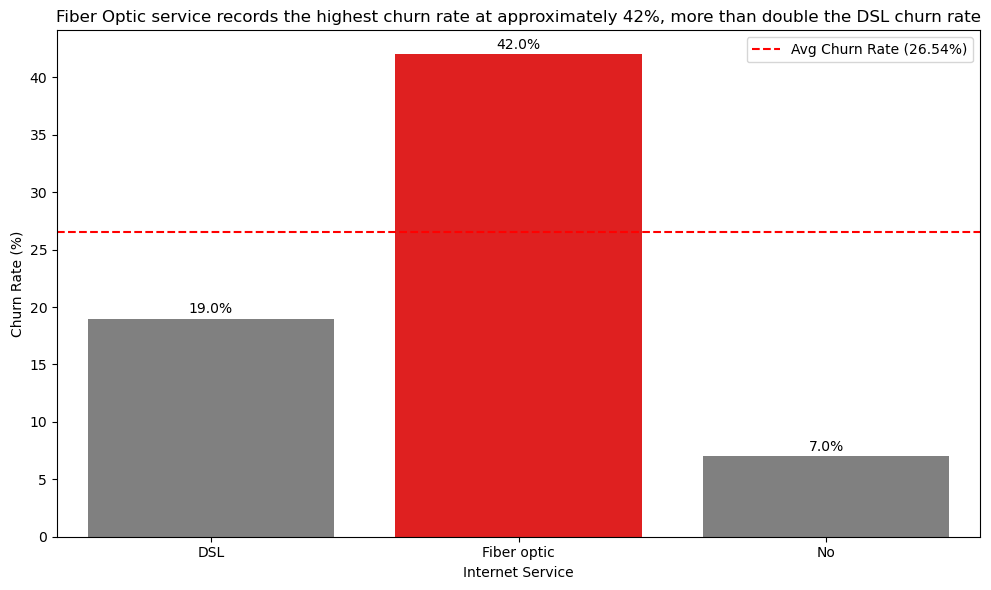

In [19]:
plt.figure(figsize = (10, 6))
ax = sns.barplot(x = 'InternetService', y= 'churn_rate', data = InternetService_churn, 
    palette =['grey', 'red', 'grey'])
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center'
    )
plt.axhline(y=26.54, color='red', linestyle='--', label='Avg Churn Rate (26.54%)')
plt.legend()
plt.title('Fiber Optic service records the highest churn rate at approximately 42%, more than double the DSL churn rate')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

## Chart 2 — Churn Rate by Contract Type

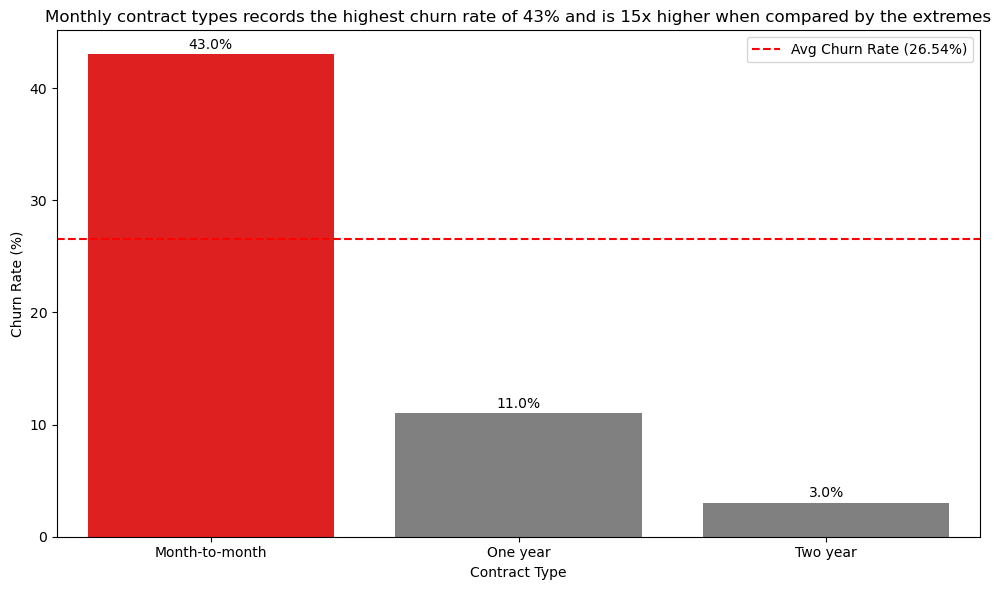

In [20]:
plt.figure(figsize = (10, 6))
ax = sns.barplot(x = 'Contract', y= 'Churn_Rate', data = ContractType_churn, 
    palette =['red', 'grey', 'grey'])
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center'
    )
plt.axhline(y=26.54, color='red', linestyle='--', label='Avg Churn Rate (26.54%)')
plt.legend()
plt.title('Monthly contract types records the highest churn rate of 43% and is 15x higher when compared by the extremes')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

## Chart 3 — Churn Rate by Payment Method

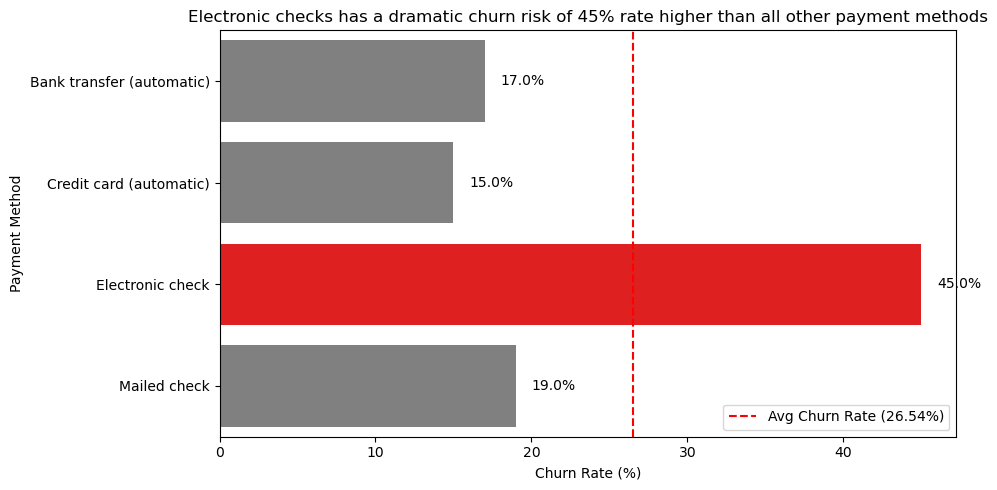

In [21]:
plt.figure(figsize = (10, 5))
ax = sns.barplot(x = 'Churn_Rate', y= 'PaymentMethod', data = PaymentMethod_ChurnRate, 
    palette =['grey', 'grey', 'red', 'grey'])

for bar in ax.patches:
    
    ax.text(
        bar.get_width() + 1.0,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.1f}%',
        va='center',
    )

plt.axvline(x=26.54, color='red', linestyle='--', label='Avg Churn Rate (26.54%)')
plt.legend(loc = 'lower right')
plt.title('Electronic checks has a dramatic churn risk of 45% rate higher than all other payment methods')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Payment Method')
plt.tight_layout()
plt.show()

## Chart 4 — Churn Rate by Online Security & Tech Support


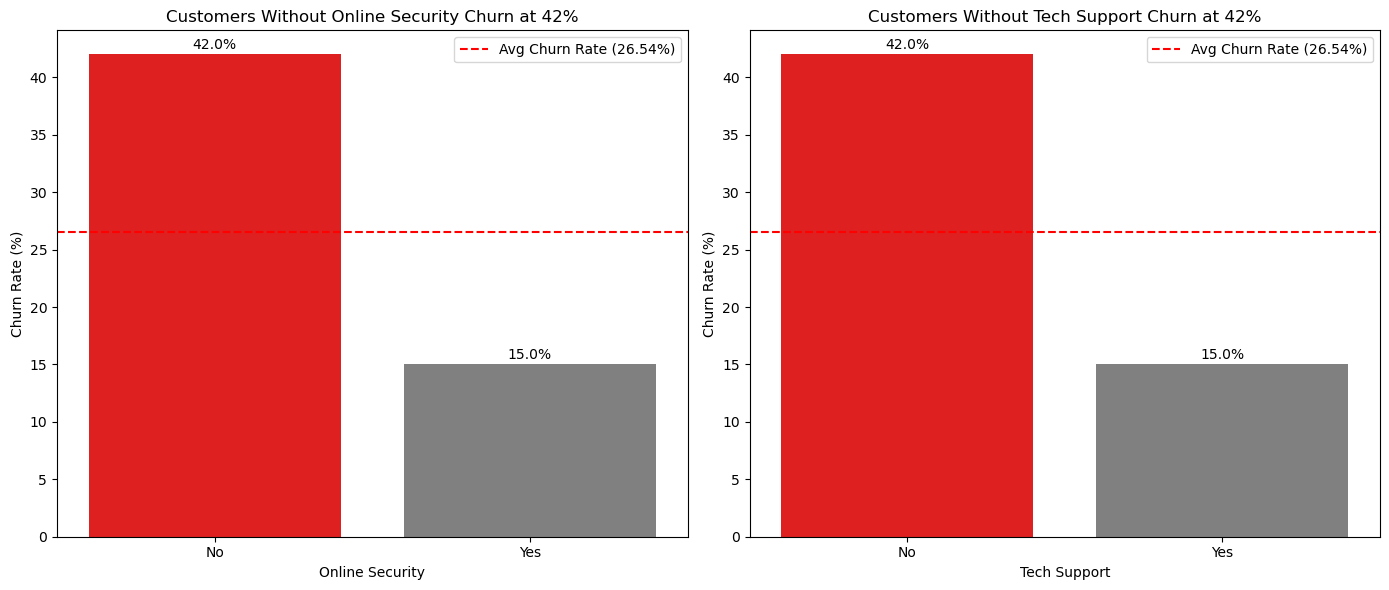

In [22]:
OnlineSecurity_ChurnRate = OnlineSecurity_ChurnRate.reset_index()
TechSupport_ChurnRate = TechSupport_ChurnRate.reset_index()

OnlineSecurity_ChurnRate1 = OnlineSecurity_ChurnRate[OnlineSecurity_ChurnRate['OnlineSecurity'] != 'No internet service']
TechSupport_ChurnRate1 = TechSupport_ChurnRate[TechSupport_ChurnRate['TechSupport'] != 'No internet service']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1 = sns.barplot(x='OnlineSecurity', y='Churn_Binary', data=OnlineSecurity_ChurnRate1, palette=['red', 'grey'], ax=ax1)
ax2 = sns.barplot(x='TechSupport', y='Churn_Binary', data=TechSupport_ChurnRate1, palette=['red', 'grey'], ax=ax2)

for bar in ax1.patches:
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center'
    )

for bar in ax2.patches:
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center'
    )

ax1.axhline(y=26.54, color='red', linestyle='--', label='Avg Churn Rate (26.54%)')
ax2.axhline(y=26.54, color='red', linestyle='--', label='Avg Churn Rate (26.54%)')
ax1.legend()
ax2.legend()
ax1.set_title('Customers Without Online Security Churn at 42%')
ax2.set_title('Customers Without Tech Support Churn at 42%')
ax1.set_xlabel('Online Security')
ax2.set_xlabel('Tech Support')
ax1.set_ylabel('Churn Rate (%)')
ax2.set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

## Chart 5 — Annual Revenue Loss by Contract Type and Internet Service

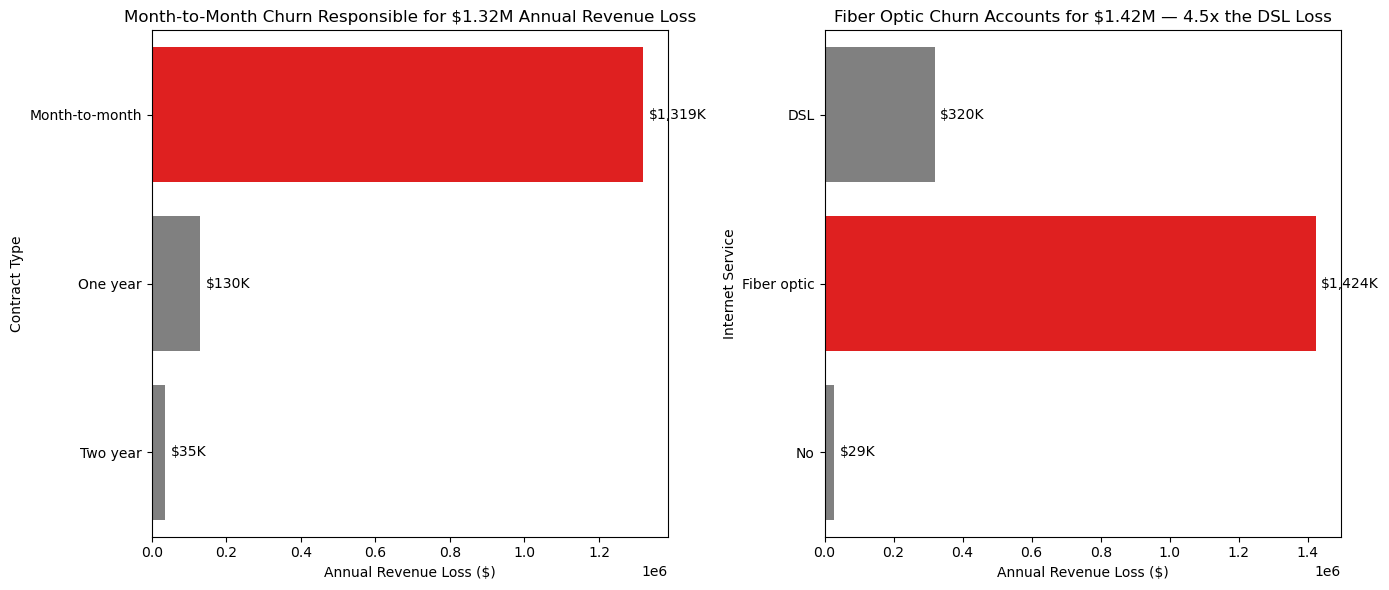

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1 = sns.barplot(x='Annual_Revenue_Loss', y='Contract', data=Contract_Revenue_Loss,
                  palette=['red', 'grey', 'grey'], ax=ax1)
ax2 = sns.barplot(x='Annual_Revenue_Loss', y='InternetService', data=InternetService_Type,
                  palette=['grey', 'red', 'grey'], ax=ax2)

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + 15000,
        bar.get_y() + bar.get_height()/2,
        f'${bar.get_width()/1000:,.0f}K',
        va='center'
    )

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + 15000,
        bar.get_y() + bar.get_height()/2,
        f'${bar.get_width()/1000:,.0f}K',
        va='center'
    )

ax1.set_title('Month-to-Month Churn Responsible for $1.32M Annual Revenue Loss')
ax2.set_title('Fiber Optic Churn Accounts for $1.42M — 4.5x the DSL Loss')
ax1.set_xlabel('Annual Revenue Loss ($)')
ax2.set_xlabel('Annual Revenue Loss ($)')
ax1.set_ylabel('Contract Type')
ax2.set_ylabel('Internet Service')

plt.tight_layout()
plt.show()

## Chart 6 — Annual Revenue Loss by Payment Method

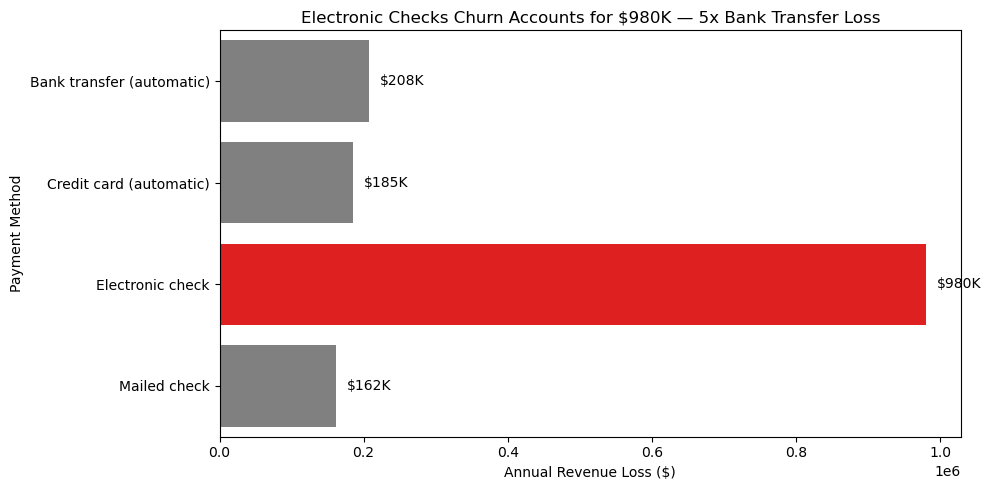

In [24]:
plt.figure(figsize = (10, 5))
ax = sns.barplot(x = 'Annual_Revenue_Loss', y= 'PaymentMethod', data = PaymentMethod_Type, 
    palette =['grey', 'grey', 'red', 'grey'])

for bar in ax.patches:
    
    ax.text(
        bar.get_width() + 15000,
        bar.get_y() + bar.get_height()/2,
        f'${bar.get_width()/1000:,.0f}K',
        va='center',
    )

#plt.axvline(x=26.54, color='red', linestyle='--', label='Avg Churn Rate (26.54%)')
#plt.legend(loc = 'lower right')
plt.title('Electronic Checks Churn Accounts for $980K — 5x Bank Transfer Loss')
plt.xlabel('Annual Revenue Loss ($)')
plt.ylabel('Payment Method')
plt.tight_layout()
plt.show()

In [25]:
avg_monthly_charges = df['MonthlyCharges'].mean()

In [26]:
total_churn = df[df['Churn'] == 'Yes'].value_counts().sum()
print(total_churn)

1869


In [27]:
avg_monthly_charges = df['MonthlyCharges'].mean()
total_churn = df[df['Churn'] == 'Yes'].value_counts().sum()
total_annual_loss = avg_monthly_charges*total_churn*12
print(f'Total Annual Revenue Loss: ${total_annual_loss:,.0f}')

Total Annual Revenue Loss: $1,452,475


In [28]:
total_churned = df['Churn_Binary'].sum()
print(f'Total Customers Churned: {total_churned:,.0f}')

Total Customers Churned: 1,869


In [29]:
25.65 - 5
churn_reduction*7043



NameError: name 'churn_reduction' is not defined

In [ ]:
#REVENUE RECOVERY CALCULATION
Current churned = 42% × 3,096 Fiber Optic customers = 1,297
Target churned = 30% × 3,096 = 929
Customers retained = 1,297 - 929 = 368
Revenue recovered = 368 × $91.50 × 12

In [41]:
#Fiber Optic 12% Churn Reduction & Revenue Recovery
Current_churned = 0.42 * 3096
print(Current_churned)

1300.32


In [42]:
Target_churned = 0.30 * 3096
print(Target_churned)

928.8


In [43]:
Customers_retained = Current_churned - Target_churned
print(Customers_retained)

371.52


In [47]:
Revenue_recovered1 = Customers_retained * 91.5 * 12

print(f'Customers retained: {Customers_retained:.0f}')
print(f'Annual revenue recovered(Fiber Optic): ${Revenue_recovered1:,.0f}')

Customers retained: 372
Annual revenue recovered(Fiber Optic): $407,929


In [33]:
#Electric Check 10% Churn Reduction & Revenue Recovery
#current_churn = churn rate x total customers
current_churn = 0.45 * 2365
print(current_churn)

1064.25


In [34]:
#Target churn = Target churn rate x total customers
target_churn = 0.35 * 2365
print(target_churn)

827.75


In [35]:
#Customers saved (retained) = Current churn - Target Churn
customers_retained = current_churn - target_churn
print(customers_retained)

236.5


In [48]:
#Annual Revenue recovery = 76.26 x customers_retained 
revenue_recovered2 = customers_retained * 76.26 * 12

print(f'Customers retained: {customers_retained:.0f}')
print(f'Annual revenue recovered (Electric Check): ${revenue_recovered2:,.0f}')

Customers retained: 236
Annual revenue recovered (Electric Check): $216,426


In [46]:
#M2M 13% Churn Reduction & Revenue Recovery
M2M_current_churn = 0.43 * 3875
M2M_target_churn = 0.30 * 3875
M2M_customers_retained = M2M_current_churn - M2M_target_churn
M2M_revenue_recovered = M2M_customers_retained * 66.40 * 12

print(f'Customers retained: {M2M_customers_retained:.0f}')
print(f'Annual revenue recovered (Month-to-Month): ${M2M_revenue_recovered:,.0f}')


Customers retained: 504
Annual revenue recovered (Month-to-Month): $401,388


In [51]:
#total revenue recovery across all three interventions
Total_revenue_recovery = Revenue_recovered1 + revenue_recovered2 + M2M_revenue_recovered
print(f'Total Revenue Recovered (All Interventions): ${Total_revenue_recovery:,.0f}')

Total Revenue Recovered (All Interventions): $1,025,743


In [52]:
# Define the values
total_annual_loss = 1452475
recovery_amount = 1025743

# Calculate the percentage
percentage_of_loss = (recovery_amount / total_annual_loss) * 100

# Display the result formatted to two decimal places
print(f"The recovery represents {percentage_of_loss:.2f}% of the total loss.")

The recovery represents 70.62% of the total loss.


## Executive Summary and Business Case

#### Problem Statement
This telecom company is experiencing a 26.54% churn rate, resulting in approximately \\$1,452,475 in annual revenue loss, representing 1,869 customers lost every year. Analysis of the company's customer data across contract types, services, and payment methods reveals that Fiber Optic service is the single largest churn driver, accounting for \\$1,424,108 of that annual loss due to a combination of the highest churn rate at 42% and the highest average monthly charge at \\$91.50. Left unaddressed, this level of churn creates a compounding growth problem. The company must continuously acquire new customers simply to replace those it is losing, making retention a direct revenue priority. This represents a critical opportunity for the Customer Success team to intervene with targeted strategies including proactive outreach, structured check-ins, and cross-functional collaboration with product and technical teams to improve the customer experience. A focused effort to reduce churn by just 5 percentage points could recover an estimated \\$273,546 in annual revenue — making the business case for CS investment clear and measurable.

#### Key Findings
1. Fiber Optic customers churn at 42%. This is more than double the DSL rate and six times higher than customers without internet — driving \\$1,424,108 in annual revenue loss, the highest of any segment. With an average monthly charge of \\$91.50, every Fiber Optic customer lost carries a disproportionately large revenue impact, making this the single highest CS priority in the dataset.
2. Month-to-month customers churn at 42.7% compared to just 2.8% for two-year contract holders — a 15x difference — accounting for \\$1,318,674 in annual revenue loss and representing the largest volume churn problem the CS team must address.
3. Customers without Online Security and Tech Support churn at approximately 42% each. This is nearly three times higher than customers with these add-ons, indicating that feature adoption is directly linked to retention and should be a core focus of the CS onboarding strategy.
4. Electronic check customers churn at 45%, the highest of any payment method, driving \\$980,040 in annual revenue loss. The friction associated with manual payment processes, including failed transactions and complex procedures, appears to erode customer trust and accelerate churn.
5. A critical cross-variable pattern emerges between payment method and contract type: 78.2% of electronic check customers are on month-to-month contracts, compared to just 38% of automatic payment customers — revealing that electronic check churn and month-to-month churn are compounding the same underlying retention problem simultaneously.

#### Prioritised CS Intervention Recommendations
Recommendation 1 (Premium Customer Retention): Fiber Optic Segment
Target Segment: Fiber Optic internet service customers (3,096 customers)
The Problem: Fiber Optic customers churn at 42% — the highest rate of any service type — driving \\$1,424,108 in annual revenue loss. With an average monthly charge of \\$91.50, every customer lost in this segment carries a disproportionately large revenue impact relative to all other segments.
The Intervention: CS interventions for this segment must reflect its premium nature. Recommended actions include dedicated CSM assignment for high-value accounts, proactive service quality reviews, and structured success plans tailored specifically to high-expectation customers. Proactive outreach and regular check-ins should focus on understanding the specific challenges Fiber Optic customers face, while retention strategies proving effective in lower-tier segments should be evaluated for relevance and compatibility with this group.
Expected Impact: A 12 percentage point churn reduction — from 42% to 30% — would retain approximately 368 customers and recover an estimated $407,929 in annual revenue. Success metrics include improved NPS scores, increased feature adoption rates, and a measurable reduction in voluntary cancellations among this segment.

Recommendation 2 (Contract Commitment Conversion): Month-to-Month Segment
Target Segment: Month-to-month contract customers (3,875 customers)
The Problem: Month-to-month customers churn at 42.7% — 15 times higher than two-year contract holders — accounting for \\$1,318,674 in annual revenue loss, the largest volume churn problem in the dataset. The data is unambiguous: the longer the contract commitment, the higher the likelihood a customer will stay.
The Intervention: CS should implement frequent check-ins and structured onboarding programmes designed to demonstrate product value early, reducing the likelihood of early cancellation. Targeted incentives — such as discounted rates, feature upgrades, or priority support — should be introduced to actively transition short-term customers into longer-term contracts, directly addressing the root cause of this churn concentration.
Expected Impact: A 13 percentage point churn reduction — from 43% to 30% — would retain approximately 492 customers and recover an estimated \\$392,000 in annual revenue. Beyond direct revenue recovery, successful contract upgrades compound retention value over time as longer-term customers consistently demonstrate lower churn rates across all segments.

Recommendation 3 (Payment Friction Resolution): Electronic Check Segment
Target Segment: Electronic check payment customers (2,365 customers)
The Problem: Electronic check customers churn at 45% — the highest rate of any payment method — driving \\$980,040 in annual revenue loss. Critically, 78.2% of electronic check customers are also on month-to-month contracts, meaning this segment and the month-to-month segment are compounding the same underlying retention problem simultaneously.
The Intervention: CS should prioritise structured onboarding and training at the earliest stages of the customer journey, with particular focus on how the electronic check process works and how customers can get the most from it. Proactive outreach to identify and resolve payment friction and bottlenecks should be an ongoing priority. Most critically, CS should advocate for collaboration with product and development teams to explore automating the electronic check process — automatic payment methods consistently show the lowest churn rates in the data, strongly suggesting that automation addresses the root cause of this churn risk directly.
Expected Impact: A targeted intervention retaining approximately 236 customers would recover an estimated \\$216,426 in annual revenue. Beyond direct revenue recovery, this recommendation carries the highest strategic efficiency of all three — given the 78.2% overlap with month-to-month customers, reducing electronic check churn simultaneously contributes to month-to-month churn reduction, meaning a single intervention addresses two of the three priority segments at once. Success metrics include reduced support ticket volume related to payment issues and measurable migration toward automatic payment methods.

#### Expected Business Impact
The three targeted CS interventions identified in this analysis — Premium Customer Retention for Fiber Optic customers, Contract Commitment Conversion for month-to-month customers, and Payment Friction Resolution for electronic check customers — represent a combined annual revenue recovery opportunity of \\$1,016,355, equivalent to approximately 70% of the company's total annual churn-related revenue loss of \\$1,452,475.
This analysis makes a clear case for where the Customer Success team should focus its energy and resources. Rather than treating churn as a company-wide problem requiring a blanket solution, the data shows that three specific, identifiable customer segments are responsible for the overwhelming majority of revenue loss — and that targeted, segment-specific CS interventions can recover the majority of that loss in a measurable and accountable way.
If only one intervention can be prioritised immediately, Fiber Optic customers represent the highest-impact starting point — combining the highest churn rate, the highest average monthly charge, and the largest single revenue recovery opportunity of \\$407,929. From there, the month-to-month and electronic check interventions follow naturally, with the added strategic efficiency that the 78.2% overlap between those two segments means a single coordinated effort addresses both problems simultaneously.
The business case is clear: a CS team equipped with the right data, the right playbooks, and the right prioritisation framework can recover over $1M in annual revenue — not through broad initiatives, but through precise, evidence-based customer intervention.